In [77]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [78]:
# set plot style
sns.set_style('whitegrid')

# load the dataset
df = pd.read_csv('heart_disease_dataset.csv')

# display initial info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [79]:
# before replace None or NaN values with Never

print('before replacing None or NaN values with Never:')
print(df['Alcohol Intake'].unique())

# replace None or NaN values with Never

df['Alcohol Intake']=df['Alcohol Intake'].fillna('Never')

# verify the changes
print('after replacing None or NaN values with Never:')
print(df['Alcohol Intake'].unique())

before replacing None or NaN values with Never:
['Heavy' nan 'Moderate']
after replacing None or NaN values with Never:
['Heavy' 'Never' 'Moderate']


In [80]:
# print top 20 rows of the dataset
df.head(20)

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,Never,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,Never,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,Never,6,No,Yes,No,2,183,Yes,Asymptomatic,0
5,77,Male,309,110,73,Never,Never,0,No,Yes,Yes,4,122,Yes,Asymptomatic,1
6,64,Female,211,105,86,Former,Heavy,8,Yes,Yes,Yes,2,120,No,Typical Angina,1
7,60,Female,208,148,83,Never,Moderate,4,No,Yes,Yes,2,113,Yes,Asymptomatic,1
8,37,Female,317,137,66,Current,Heavy,3,No,Yes,Yes,5,114,No,Non-anginal Pain,0
9,63,Male,204,141,68,Former,Heavy,8,No,Yes,No,3,107,No,Asymptomatic,1


In [81]:
# lebel encoding for categorical features
le = LabelEncoder()
categorical_cols=df.select_dtypes(include=['object']).columns

# create a copy of encoded dataset
df_encoded = df.copy()

print('encoding mapping :')
print('-' * 30)

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col} : {mapping}')

encoding mapping :
------------------------------
Gender : {'Female': np.int64(0), 'Male': np.int64(1)}
Smoking : {'Current': np.int64(0), 'Former': np.int64(1), 'Never': np.int64(2)}
Alcohol Intake : {'Heavy': np.int64(0), 'Moderate': np.int64(1), 'Never': np.int64(2)}
Family History : {'No': np.int64(0), 'Yes': np.int64(1)}
Diabetes : {'No': np.int64(0), 'Yes': np.int64(1)}
Obesity : {'No': np.int64(0), 'Yes': np.int64(1)}
Exercise Induced Angina : {'No': np.int64(0), 'Yes': np.int64(1)}
Chest Pain Type : {'Asymptomatic': np.int64(0), 'Atypical Angina': np.int64(1), 'Non-anginal Pain': np.int64(2), 'Typical Angina': np.int64(3)}


In [82]:
# save the lebel encoded file
# df_encoded.to_csv('heart_disease_dataset_encoded.csv', index=False)

df_encoded.head(20)


,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,2,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,2,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,2,6,0,1,0,2,183,1,0,0
5,77,1,309,110,73,2,2,0,0,1,1,4,122,1,0,1
6,64,0,211,105,86,1,0,8,1,1,1,2,120,0,3,1
7,60,0,208,148,83,2,1,4,0,1,1,2,113,1,0,1
8,37,0,317,137,66,0,0,3,0,1,1,5,114,0,2,0
9,63,1,204,141,68,1,0,8,0,1,0,3,107,0,0,1


In [83]:
# feature scaling
numerical_cols =['Age','Cholesterol','Blood Pressure','Heart Rate','Stress Level','Blood Sugar']
scaler=StandardScaler()

# create a copy of scaled data
df_scaled = df_encoded.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])


In [84]:
# save the preprocessed dataset to a new CSV file
# df_scaled.to_csv('heart_disease_dataset_preprocessed.csv', index=False)

df_scaled.head(20)

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,1.444534,0,-0.379005,-0.617287,-1.150139,0,0,1,0,0,1,0.831917,-0.434581,1,1,1
1,-0.273104,1,-0.793616,1.126782,-1.498561,0,2,5,0,0,0,1.185323,-1.770413,1,3,0
2,0.044977,1,-0.275353,-1.678894,-1.063034,2,0,3,1,0,1,-0.228300,1.664583,1,1,1
3,1.062836,0,-1.000921,-1.716808,-0.627507,0,2,4,0,1,0,0.478511,-0.761724,1,2,0
4,0.617523,0,-1.346429,1.050953,1.201706,2,2,6,0,1,0,-1.288517,1.310178,1,0,0
5,1.571766,1,1.020304,-0.958518,-0.540402,2,2,0,0,1,1,-0.581706,-0.352796,1,0,1
6,0.744755,0,-0.672688,-1.148090,0.591968,1,0,8,1,1,1,-1.288517,-0.407320,0,3,1
7,0.490290,0,-0.724514,0.482235,0.330652,2,1,4,0,1,1,-1.288517,-0.598153,1,0,1
8,-0.972883,0,1.158507,0.065175,-1.150139,0,0,3,0,1,1,-0.228300,-0.570891,0,2,0
9,0.681139,1,-0.793616,0.216833,-0.975929,1,0,8,0,1,0,-0.935112,-0.761724,0,0,1


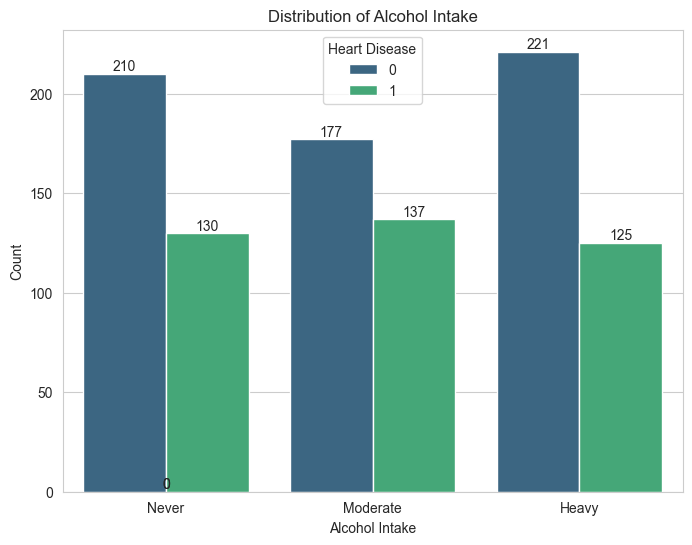

In [85]:
# plot 1 Alcohol Intake distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Alcohol Intake',hue='Heart Disease', data=df, palette='viridis', order=['Never', 'Moderate', 'Heavy'])

# add count labels on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Alcohol Intake')
plt.xlabel('Alcohol Intake')
plt.ylabel('Count')
plt.show()

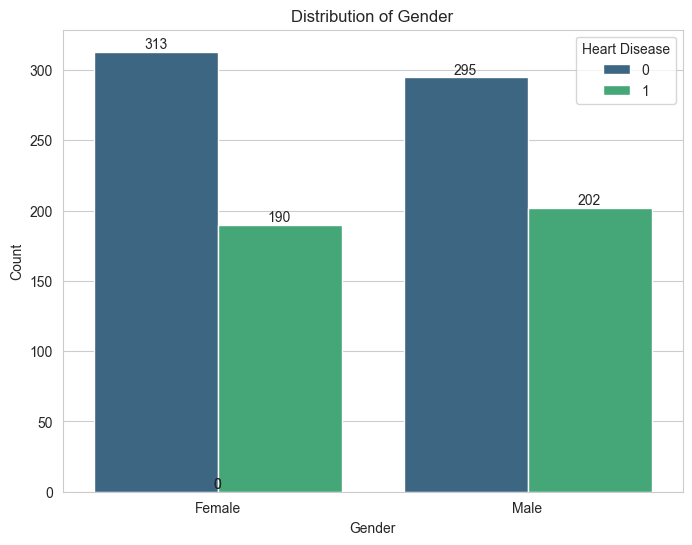

In [86]:
# plot 2 Gender distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Gender',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

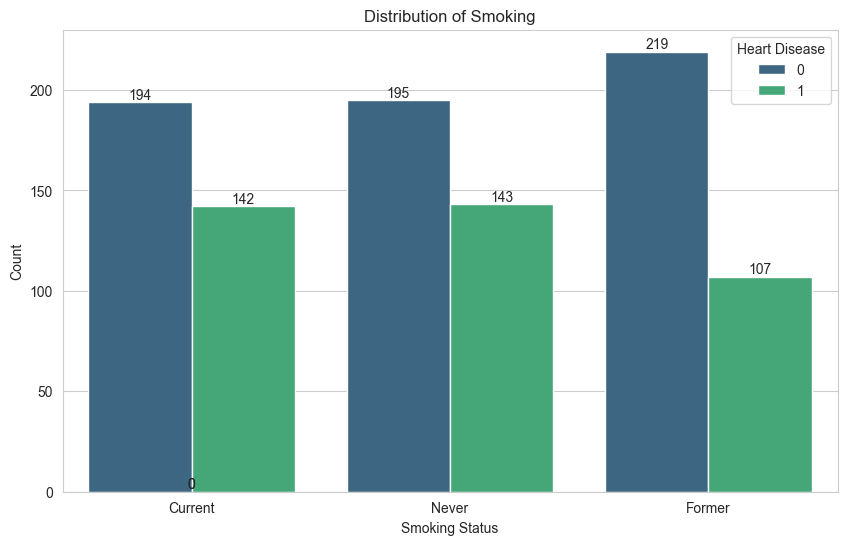

In [87]:
# plot 3 Smoking distribution
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Smoking',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Smoking')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.show()

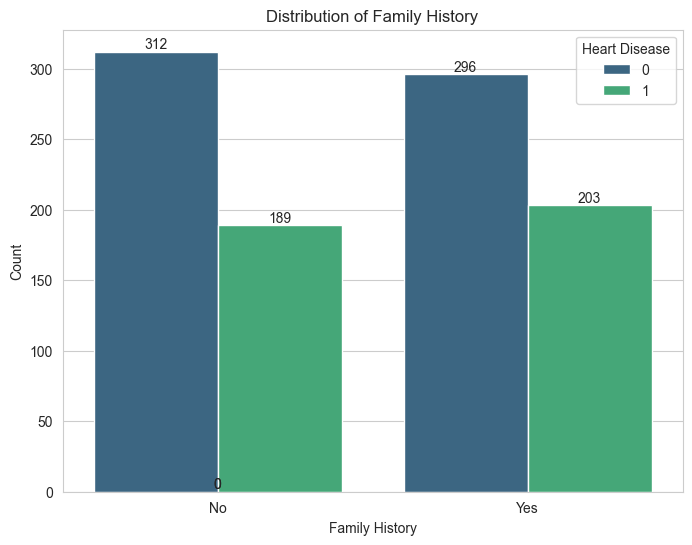

In [88]:
# plot 4 Family History distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Family History',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Family History')
plt.xlabel('Family History')
plt.ylabel('Count')
plt.show()

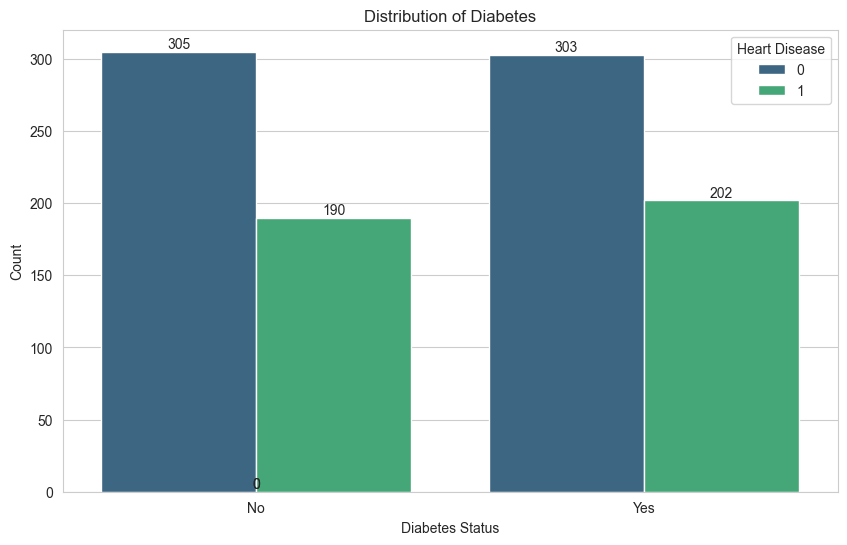

In [89]:
# plot 5 Diabetes distribution
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Diabetes',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Diabetes')
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.show()

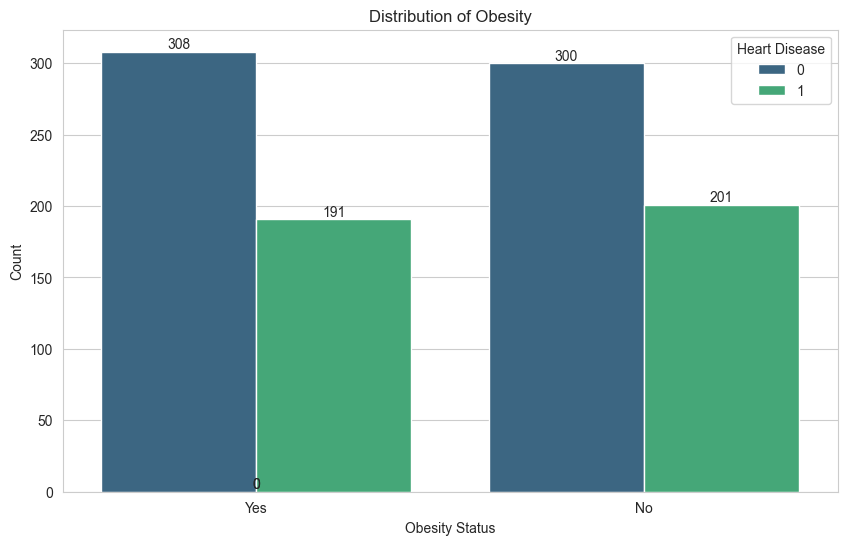

In [90]:
# plot 6 Obesity distribution
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Obesity',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Obesity')
plt.xlabel('Obesity Status')
plt.ylabel('Count')
plt.show()

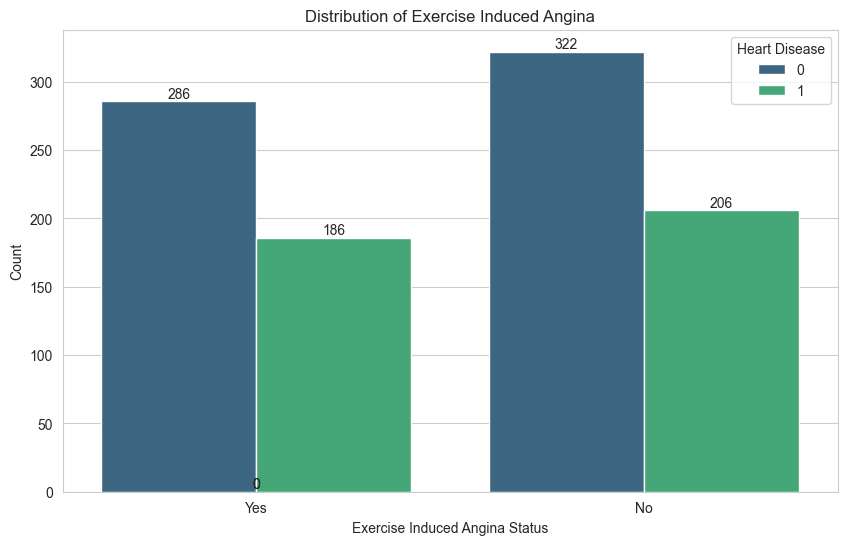

In [91]:
# plot 7 Exercise Induced Angina distribution
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Exercise Induced Angina',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Exercise Induced Angina')
plt.xlabel('Exercise Induced Angina Status')
plt.ylabel('Count')
plt.show()

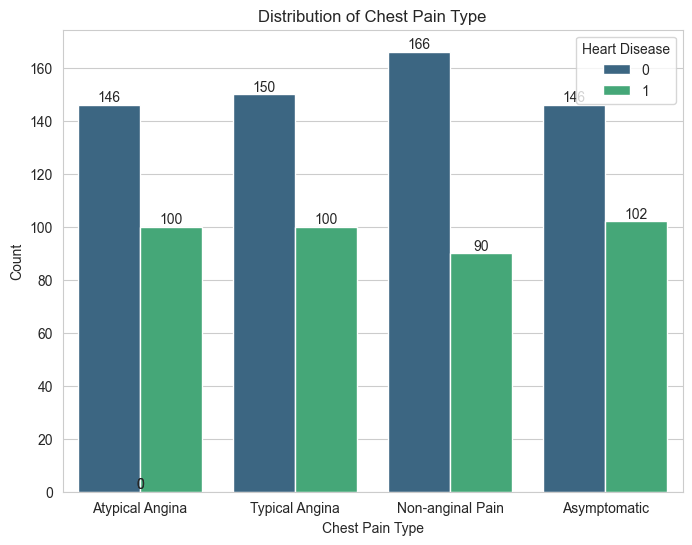

In [92]:
# plot 8 Chest Pain Type distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(x='Chest Pain Type',hue='Heart Disease', data=df, palette='viridis')

# add count annotations on top of the bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',          # count value
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribution of Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

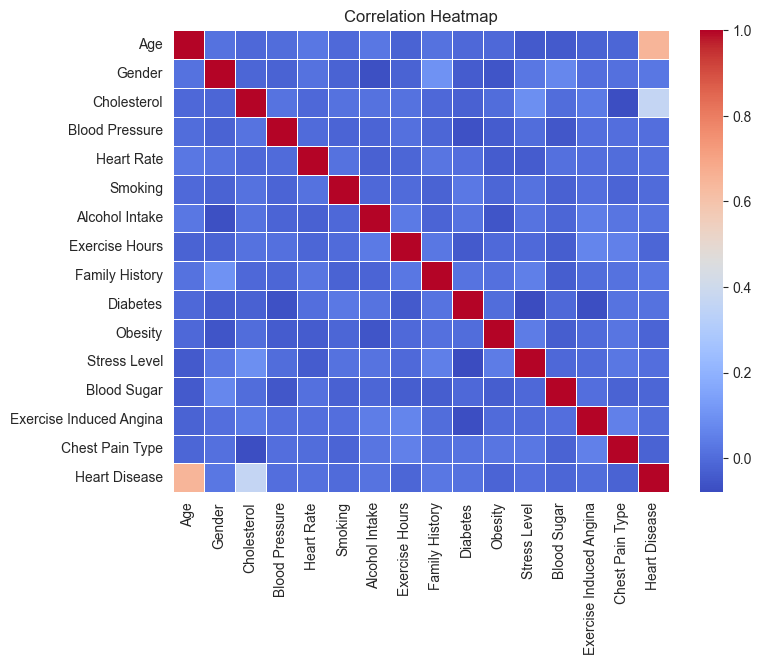

In [93]:
# plot 9 correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

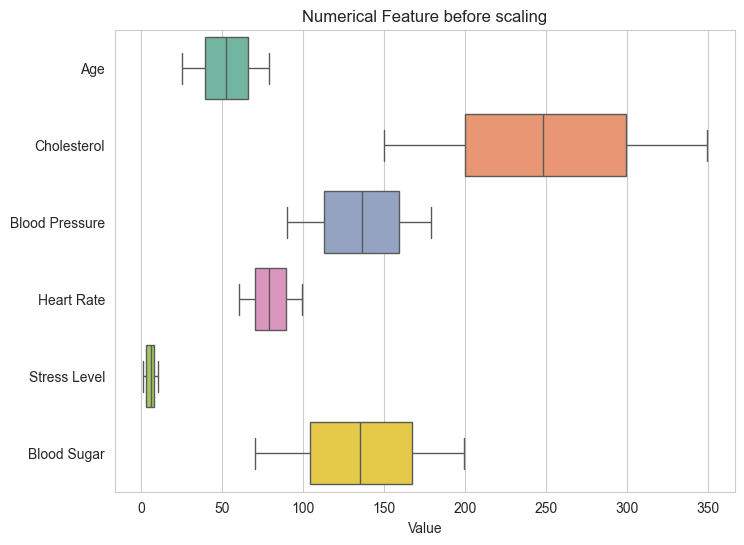

In [94]:
# plot 10 numerical feature before scaling
plt.figure(figsize=(8,6))
sns.boxplot(data=df_encoded[numerical_cols], orient='h',palette='Set2')
plt.title('Numerical Feature before scaling')
plt.xlabel('Value')
plt.show()


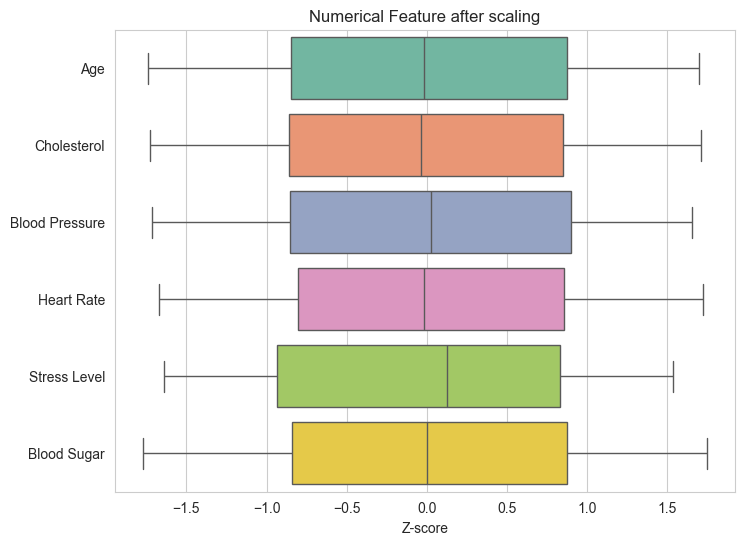

In [95]:
# plot 11 numerical feature after scaling
plt.figure(figsize=(8,6))
sns.boxplot(data=df_scaled[numerical_cols], orient='h',palette='Set2')
plt.title('Numerical Feature after scaling')
plt.xlabel('Z-score')
plt.show()


In [96]:
# split the data into training and testing sets

from sklearn.model_selection import train_test_split

# features and target
X = df_scaled.drop('Heart Disease', axis=1)
y = df_scaled['Heart Disease']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [97]:
# train the KNN model using binary  tree search 

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='kd_tree',   # binary tree structure
    metric='euclidean'
)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'kd_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [98]:
# evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90       122
           1       0.86      0.82      0.84        78

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.88       200


Confusion Matrix:
 [[112  10]
 [ 14  64]]


In [99]:
# try different values of k
for k in range(1, 16):
    model = KNeighborsClassifier(n_neighbors=k, algorithm='kd_tree')
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"K={k} → Accuracy={acc:.4f}")

K=1 → Accuracy=0.7700
K=2 → Accuracy=0.8000
K=3 → Accuracy=0.8450
K=4 → Accuracy=0.8450
K=5 → Accuracy=0.8800
K=6 → Accuracy=0.8550
K=7 → Accuracy=0.8700
K=8 → Accuracy=0.8700
K=9 → Accuracy=0.8600
K=10 → Accuracy=0.8600
K=11 → Accuracy=0.8650
K=12 → Accuracy=0.8800
K=13 → Accuracy=0.8850
K=14 → Accuracy=0.8700
K=15 → Accuracy=0.8650


In [100]:
# experiment with different algorithms
KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree')

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [101]:
# logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.87


In [102]:
# decision tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [103]:
# random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.99


In [104]:
# support vector machine
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.89


In [105]:
# gredient boosting
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [106]:
# nural network
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.935
